In [ ]:
#Amit pawar
#Prn:25070126501
#impliment LDA on Forest Cover Type Dataset

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning.
# numpy for numerical operations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import fetch_covtype

In [ ]:
# Load the 'covtype.csv' dataset into a pandas DataFrame.
# Then, display the first 10 rows of the DataFrame to inspect the data.
df = pd.read_csv("/content/covtype.csv")
df.head(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
# Fetch the forest cover type dataset from sklearn's datasets module.
data = fetch_covtype()
# Randomly select 5000 indices to create a subset of the data.
subset_indices = np.random.choice(len(data.data), 5000, replace=False)

# Use the selected indices to create a smaller feature set (x) and target set (y).
x = data.data[subset_indices]
y = data.target[subset_indices]
# Print the shape of the created subset to confirm its dimensions.
print("Dataset shape", x.shape)

Dataset shape (5000, 54)


In [ ]:
# Import StandardScaler for feature scaling.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit the scaler to the data and transform the data in one step.
# This scales the features to have zero mean and unit variance.
x = scaler.fit_transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

STEP 4 - logistic Regrssion BEFORE LDA

In [ ]:
# and multi_class='ovr' handles multi-class classification using One-vs-Rest strategy.
model_before_lda = LogisticRegression(max_iter=500, random_state=42, multi_class='ovr')

# Fit the model using the training data
model_before_lda.fit(x_train, y_train)

# Predict class labels for the test dataset
y_pred_before_lda = model_before_lda.predict(x_test)

# Evaluate model performance by calculating accuracy before applying LDA
accuracy_before_lda = accuracy_score(y_test, y_pred_before_lda)
print("Accuracy before LDA:", accuracy_before_lda)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy before LDA: 0.714


# Step 5 :- Apply LDA Dimensionality Reduction

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
x_train_lda = lda.fit_transform(x_train, y_train)

# Step 6 :-Explained variance Ratio

In [ ]:
expVar = lda.explained_variance_ratio_
explained_variance_df = pd.DataFrame({
    "LDA_component": [f"LD{i+1}" for i in range(len(expVar))],
    "Explained_variance": expVar
})
explained_variance_df

,LDA_component,Explained_variance
0,LD1,0.683919
1,LD2,0.174636


# Step :- Train-Test Split(After LDA)

In [ ]:
x_train_lda, x_test_lda, y_train_lda, y_test_lda = train_test_split(x_train_lda, y_train, test_size=0.2, random_state=42)


Step 8:- Logistic LDA

> Add blockquote



In [ ]:
model_after_lda = LogisticRegression(max_iter=500, random_state=42, multi_class='ovr')
model_after_lda.fit(x_train_lda, y_train_lda)
y_pred_after_lda = model_after_lda.predict(x_test_lda)
accuracy_after_lda = accuracy_score(y_test_lda, y_pred_after_lda)
print("Accuracy After LDA:", round(accuracy_after_lda, 3))

Accuracy After LDA: 0.694


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


# Step 9:- Rrsult Comparison Table

In [ ]:
comarison_df = pd.DataFrame({
    "Model":["logistic regression before LDA", "logistic regression after LDA"],
    "Accuracy":[round(accuracy_before_lda, 3), round(accuracy_after_lda, 3)]
})
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


[link text](https://)Step 10 :- visulazzation

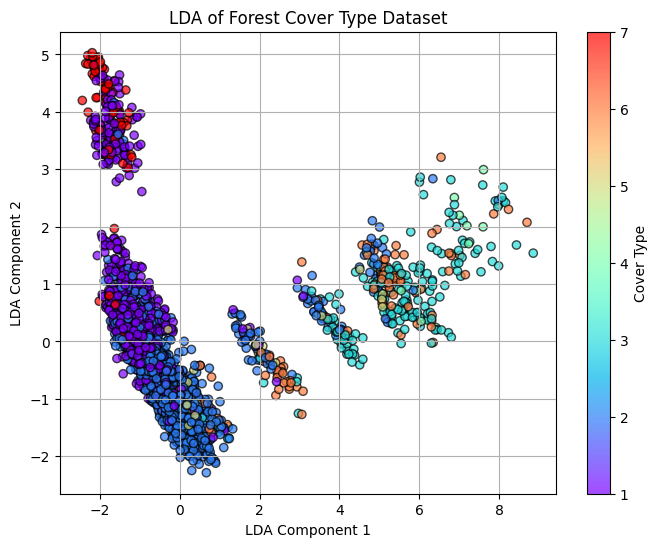

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    x_train_lda[:, 0],
    x_train_lda[:, 1],
    c=y_train_lda,
    cmap='rainbow',
    edgecolor='k',
    alpha=0.7
)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA of Forest Cover Type Dataset")
plt.colorbar(label='Cover Type')
plt.grid(True)
plt.show()

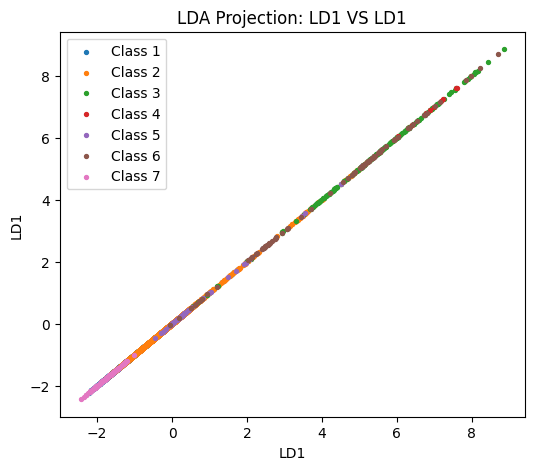

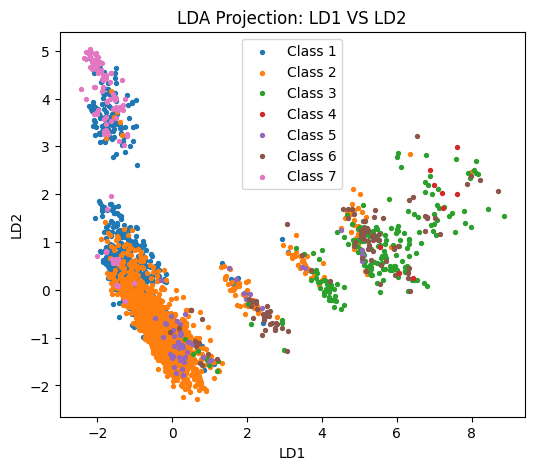

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use y_train_lda to get unique classes for consistency with plotted data
classes = np.unique(y_train_lda)

def plot_lda_pair(X_lda, y, c1, c2):
    plt.figure(figsize=(6,5))

    for cls in classes:
        plt.scatter(X_lda[y==cls, c1],
                    X_lda[y==cls, c2],
                    s = 8,
                    label = f"Class {cls}")

    plt.xlabel(f"LD{c1+1}")
    plt.ylabel(f"LD{c2+1}")
    plt.title(f"LDA Projection: LD{c1+1} VS LD{c2+1}")
    plt.legend() # Call the function
    plt.show()

# Replace X_lda with x_train_lda and y with y_train_lda
# Adjust range to lda.n_components to avoid IndexError
for i in range(lda.n_components):
    plot_lda_pair(x_train_lda, y_train_lda, 0, i)